### KERAS CLASSIFIER MODELING

The following **Keras Classifier models** are built:

_Model KE1_     
The class imbalance is addressed by using class weight. The model is optimized.

_Model KE2_   
The best threshold that maximizes profit is used.

_Model KE3_    
Two-stage feature selection is applied using Random Forest and SelectKBest.

_Model KE4_    
Feature selection is applied using Random Forest Classifier.

_Model KE5_    
Feature selection is applied using SelectKBest.

The following **metrics** are determined:    
_AUC_    
_Accuracy_    
_Precision_       
_Recall_    
_F2 Score_       
_Profit/Loss_    

The best model is chosen based on business goals that consider the relative cost of missing a churner (_false negatives_ - predicted not to churn but churned, loss of lifetime value), cost of false alarms (_false positives_ - predicted to churn but stayed, cost of retention offer) and _true positives_ (predicted to stay and actually stayed, saved lifetime value less the cost of retention offer).

In customer churn, missing churners (_recall_) is more expensive than false alarms (_precision_).  Recall is, therefore, optimized at the expense of precision and accuracy.

**Hyperparameters Tuning**    
Model hyperparameters are optimized using grid search to maximize model performance particularly addressing overfitting.  

**Feature Importance**     
The features and their importances are examined to verify the magnitude of features influence on customer churn.   

**Feature Selection**    
Feature selection reduces the number of features to improve the model and to lessen noise. When there is less noise, the interpretability of feature importance improves. Noise in this context is irrelevant information that obscures underlying patterns or relationships the model is trying to learn.  

**Sample Predictions**     
Sample predictions are demonstrated on unseen data.

**Import the required libraries**

In [ ]:
!pip install scikit-learn==1.3.2
!pip install scikeras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, precision_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.feature_selection import SelectFromModel, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.utils.class_weight import compute_class_weight

  Using cached scikit_learn-1.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (10.8 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.8.0
    Uninstalling scikit-learn-1.8.0:
      Successfully uninstalled scikit-learn-1.8.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikeras 0.13.0 requires scikit-learn>=1.4.2, but you have scikit-learn 1.3.2 which is incompatible.
umap-learn 0.5.11 requires scikit-learn>=1.6, but you have scikit-learn 1.3.2 which is incompatible.
spopt 0.7.0 requires scikit-learn>=1.4.0, but you have scikit-learn 1.3.2 which is incompatible.
esda 2.9.0 requires scikit-learn>=1.4, but you have scikit-learn 1.3.2 which is incompatible.
mapclassify 2.10.0 requires scikit-learn>=1.4

In [ ]:
# Load the cleaned dataset
df = pd.read_csv('cleaned_data.csv')

In [ ]:
# Verify info prior to modeling
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7937 entries, 0 to 7936
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  7937 non-null   object 
 1   age                     7937 non-null   int64  
 2   country                 7937 non-null   object 
 3   city                    7937 non-null   object 
 4   customer_segment        7937 non-null   object 
 5   tenure_months           7937 non-null   int64  
 6   signup_channel          7937 non-null   object 
 7   contract_type           7937 non-null   object 
 8   monthly_logins          7937 non-null   int64  
 9   weekly_active_days      7937 non-null   int64  
 10  avg_session_time        7937 non-null   float64
 11  features_used           7937 non-null   int64  
 12  usage_growth_rate       7937 non-null   float64
 13  last_login_days_ago     7937 non-null   int64  
 14  monthly_fee             7937 non-null   

In [ ]:
# Define X and y
X = df.drop(['churn'], axis=1)
y = df['churn']

In [ ]:
# Split to train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [ ]:
# Define numeric features
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()
numerical_columns

['age',
 'tenure_months',
 'monthly_logins',
 'weekly_active_days',
 'avg_session_time',
 'features_used',
 'usage_growth_rate',
 'last_login_days_ago',
 'monthly_fee',
 'payment_failures',
 'support_tickets',
 'avg_resolution_time',
 'csat_score',
 'escalations',
 'email_open_rate',
 'marketing_click_rate',
 'nps_score',
 'referral_count',
 'churn',
 'tenure_fee_interaction']

In [ ]:
# Define numeric_cols less the target variable 'churn'
numeric_cols = ['age','tenure_months','monthly_logins','weekly_active_days','avg_session_time','features_used',
                'usage_growth_rate','last_login_days_ago','monthly_fee','payment_failures','support_tickets',
                'avg_resolution_time','csat_score','escalations','email_open_rate','marketing_click_rate',
                'nps_score','referral_count','tenure_fee_interaction']

print(f'There are {len(numeric_cols)} numeric columns.')

There are 19 numeric columns.


In [ ]:
# Verify categorical features for encoding
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['gender',
 'country',
 'city',
 'customer_segment',
 'signup_channel',
 'contract_type',
 'payment_method',
 'discount_applied',
 'price_increase_last_3m',
 'complaint_type',
 'survey_response']

In [ ]:
# Define the ordinal and nominal features
ordinal_cols = ['contract_type','survey_response']
nominal_cols = ['gender', 'country', 'city', 'customer_segment', 'signup_channel', 'payment_method',
                'discount_applied', 'price_increase_last_3m', 'complaint_type']

print(f'There are {len(ordinal_cols)} ordinal columns and {len(nominal_cols)} nominal columns.')

There are 2 ordinal columns and 9 nominal columns.


In [ ]:
# Verify 'contract_type' and 'survey_response'

print(df['contract_type'].value_counts(), '\n')
print(df['survey_response'].value_counts())

contract_type
Monthly      3941
Quarterly    2421
Yearly       1575
Name: count, dtype: int64 

survey_response
Satisfied      3940
Neutral        2385
Unsatisfied    1612
Name: count, dtype: int64


**Model KE1**    
The Keras Classifier is like a bridge that allows the use of deep learning models built by Keras (e.g., a neural network) inside the scikit-learn environment.

In [ ]:
# Set seed
import random

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Define specific categories for the Ordinal Encoder
ordinal_categories = [
    ['Monthly', 'Quarterly', 'Yearly'],      # contract_type
    ['Unsatisfied', 'Neutral', 'Satisfied']  # survey_response
]

In [ ]:
# Update the Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("nom", OneHotEncoder(drop='if_binary', handle_unknown="ignore"), nominal_cols),
        ("ord", OrdinalEncoder(categories=ordinal_categories), ordinal_cols)
    ]
)

In [ ]:
# Define the callback for early stop (prevents overfitting and reduces training time)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
# Fit and transform data using preprocessor
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [ ]:
# Define create model function
tf.random.set_seed(42)
def create_model(optimizer='adam', neurons=50, activation='relu', dropout_rate=0.2, input_shape=None):
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Dense(neurons,
                                    activation=activation,
                                    input_shape=(X_train_transformed.shape[1:])))
    model.add(Dropout(dropout_rate))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
# Define the parameter grid
param_grid = {
    'model__neurons': [25, 50, 100],
    'model__activation': ['relu', 'tanh'],
    'model__optimizer': ['adam', 'sgd'],
    'model__dropout_rate': [0.2, 0.3],
    'batch_size': [16, 32],
    'epochs': [100]
}

In [ ]:
# Address class imbalance with class_weight
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{0: 0.5517031630170316, 1: 5.3352941176470585}


In [ ]:
# Set seed to control randomness in neural networks
tf.random.set_seed(42)

# Build the model, grid search and fit including class_weight and callbacks
model = KerasClassifier(model=create_model, input_shape=X_train_transformed.shape[1:], verbose=0)

grid = HalvingRandomSearchCV(model, param_grid, cv=3, scoring="f1", n_jobs=-1)
grid_result = grid.fit(X_train_transformed, y_train, class_weight=class_weights, callbacks=[early_stop])

print(grid_result.best_params_, '\n')
print(grid_result.best_score_)

{'model__optimizer': 'sgd', 'model__neurons': 100, 'model__dropout_rate': 0.2, 'model__activation': 'tanh', 'epochs': 100, 'batch_size': 16} 

0.09477124183006536


In [ ]:
# Access the optimized grid_result model
grid_result_opt = grid_result.best_estimator_
grid_result_opt

,model,<function cre...x7d23e0896ac0>
,build_fn,None
,warm_start,False
,random_state,None
,optimizer,'rmsprop'
,loss,None
,metrics,None
,batch_size,16
,validation_batch_size,None
,verbose,0
,callbacks,None


In [ ]:
# Accuracy of model on train and test data
grid_result_opt_acc_train = grid_result_opt.score(X_train_transformed, y_train)
grid_result_opt_acc_test = grid_result_opt.score(X_test_transformed, y_test)

print(f'The train accuracy of the model is {grid_result_opt_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {grid_result_opt_acc_test*100:.2f}%')

The train accuracy of the model is 81.70%
The test accuracy of the model is 75.31%


In [ ]:
# Generate classification report KE1
y_pred_KE1 = grid_result_opt.predict(X_test_transformed)

print(classification_report(y_test, y_pred_KE1))

              precision    recall  f1-score   support

           0       0.94      0.77      0.85      1439
           1       0.20      0.55      0.29       149

    accuracy                           0.75      1588
   macro avg       0.57      0.66      0.57      1588
weighted avg       0.87      0.75      0.80      1588



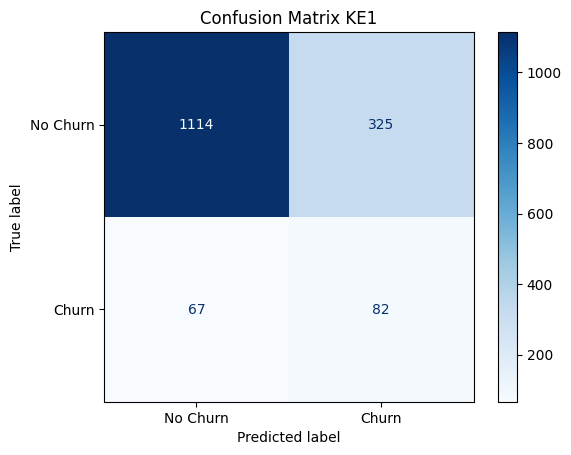

In [ ]:
# Display confusion matrix KE1
conf_matrix_KE1 = confusion_matrix(y_test, y_pred_KE1)
disp_KE1 = ConfusionMatrixDisplay(conf_matrix_KE1, display_labels=['No Churn','Churn'])
disp_KE1.plot(cmap='Blues')
plt.title('Confusion Matrix KE1')
plt.show()

In [ ]:
# Values for false positive (fp_KE1), false negative (fn_KE1), true positive (tp_KE1) and true negative (tn_KE1)
fp_KE1 = conf_matrix_KE1[0][1]
fn_KE1 = conf_matrix_KE1[1][0]
tp_KE1 = conf_matrix_KE1[1][1]
tn_KE1 = conf_matrix_KE1[0][0]

print(f' fp_KE1: {fp_KE1} \n fn_KE1: {fn_KE1} \n tp_KE1: {tp_KE1} \n tn_KE1: {tn_KE1}')

 fp_KE1: 325 
 fn_KE1: 67 
 tp_KE1: 82 
 tn_KE1: 1114


In [ ]:
# Calculations for accuracy, precision, recall
accuracy_KE1 = (tp_KE1 + tn_KE1)/len(y_test)
precision_KE1 = tp_KE1/(tp_KE1 + fp_KE1)
recall_KE1 = tp_KE1/(tp_KE1 + fn_KE1)

print(f'Accuracy: {accuracy_KE1:.2f}')
print(f'Precision: {precision_KE1:.2f}')
print(f'Recall: {recall_KE1:.2f}')
print(f'-'*15)

Accuracy: 0.75
Precision: 0.20
Recall: 0.55
---------------


In [ ]:
# Calculate F2 score
beta = 2
F2_score_KE1 = (1 + beta**2) * (precision_KE1 * recall_KE1) / (beta**2 * precision_KE1 + recall_KE1)

print(f'The F2 score is {F2_score_KE1:.4f}')

The F2 score is 0.4088


**Profit/Loss analysis**     
The profit/loss analysis compares the relative performance of the models financially. For demonstration purposes, the following values are used:     
**L** = value of retaining a churner (lifetime value) is \$500      
**C** = cost of retention action is \$40     
True positives (**TP**) are correctly identified churners (retention action is spent but the value is saved).   
False positives (**FP**) stay but predicted to leave (retention action is spent but no value is saved).    
False negatives (**FN)** are predicted not to leave but leave (no retention action spent but value is lost).    
True negatives (**TN**) are correctly predicted not to leave (no retention action spent and no value is lost).

In [ ]:
# Profit/loss analysis
L=500
C=40
Profit_Loss_KE1 = tp_KE1*(L - C) - fp_KE1*C - fn_KE1*L

print(f'The profit or loss is ${Profit_Loss_KE1}')

The profit or loss is $-8780


**ROC Curve**    
The ROC Curve is plotted and the optimum threshold is obtained.

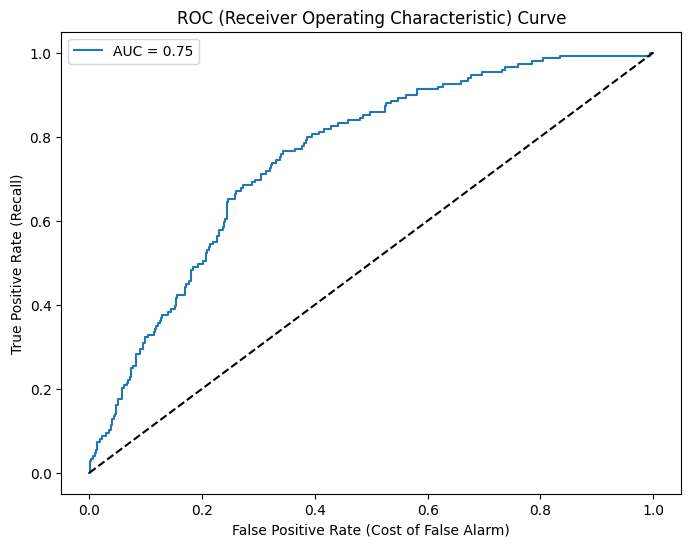

In [ ]:
# Plot the ROC Curve
y_probs_KE1 = grid_result_opt.predict_proba(X_test_transformed)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_KE1)
auc_KE2 = round(roc_auc_score(y_test, y_probs_KE1), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs_KE1):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [ ]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_KE1 = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold_KE1 :.4f}')

The optimal threshold is 0.3828


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve

In [ ]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_KE1)
avg_precision = average_precision_score(y_test, y_probs_KE1)

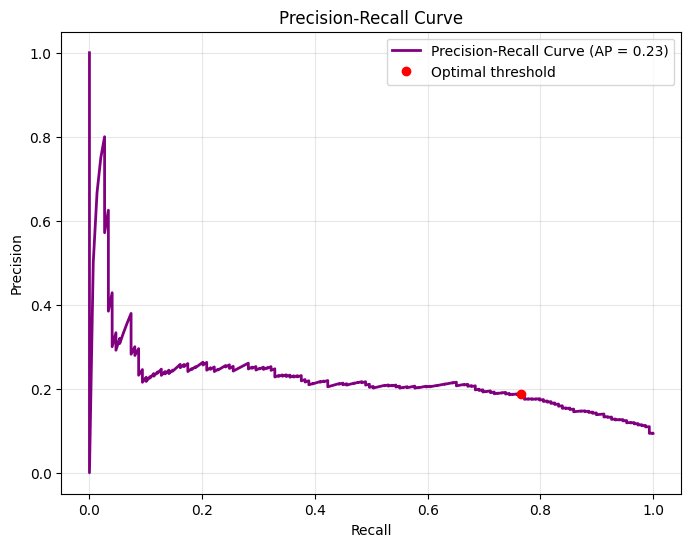

In [ ]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold_KE1))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [ ]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(-0.2, 0.80, 0.05)
for threshold in thresholds:
    preds = (y_probs_KE1 >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=-0.20 | Precision=0.09 | Recall=1.00
Threshold=-0.15 | Precision=0.09 | Recall=1.00
Threshold=-0.10 | Precision=0.09 | Recall=1.00
Threshold=-0.05 | Precision=0.09 | Recall=1.00
Threshold=-0.00 | Precision=0.09 | Recall=1.00
Threshold=0.05 | Precision=0.10 | Recall=0.99
Threshold=0.10 | Precision=0.11 | Recall=0.98
Threshold=0.15 | Precision=0.13 | Recall=0.95
Threshold=0.20 | Precision=0.14 | Recall=0.91
Threshold=0.25 | Precision=0.15 | Recall=0.86
Threshold=0.30 | Precision=0.16 | Recall=0.83
Threshold=0.35 | Precision=0.18 | Recall=0.78
Threshold=0.40 | Precision=0.19 | Recall=0.74
Threshold=0.45 | Precision=0.21 | Recall=0.67
Threshold=0.50 | Precision=0.20 | Recall=0.55
Threshold=0.55 | Precision=0.22 | Recall=0.49
Threshold=0.60 | Precision=0.21 | Recall=0.39
Threshold=0.65 | Precision=0.23 | Recall=0.33
Threshold=0.70 | Precision=0.26 | Recall=0.28
Threshold=0.75 | Precision=0.25 | Recall=0.19


In [ ]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs_KE1 >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.1999999999999999


**Model KE2** uses the best threshold

In [ ]:
# Define Model KE2 threshold
threshold_KE2 = best_threshold

In [ ]:
# Use the threshold that maximizes profit
y_pred_KE2 = (y_probs_KE1 >= best_threshold).astype(int)

In [ ]:
# Generate classification report KE2

print(classification_report(y_test, y_pred_KE2))

              precision    recall  f1-score   support

           0       0.98      0.41      0.58      1439
           1       0.14      0.91      0.24       149

    accuracy                           0.45      1588
   macro avg       0.56      0.66      0.41      1588
weighted avg       0.90      0.45      0.54      1588



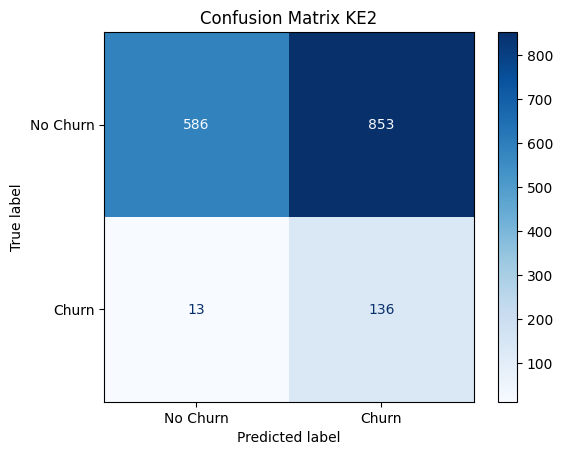

In [ ]:
# Display confusion matrix KE2
conf_matrix_KE2 = confusion_matrix(y_test, y_pred_KE2)
disp_KE2 = ConfusionMatrixDisplay(conf_matrix_KE2, display_labels=['No Churn','Churn'])
disp_KE2.plot(cmap='Blues')
plt.title('Confusion Matrix KE2')
plt.show()

In [ ]:
# Values for false positive (fp_KE2), false negative (fn_KE2), true positive (tp_KE2) and true negative (tn_KE2)
fp_KE2 = conf_matrix_KE2[0][1]
fn_KE2 = conf_matrix_KE2[1][0]
tp_KE2 = conf_matrix_KE2[1][1]
tn_KE2 = conf_matrix_KE2[0][0]

print(f' fp_KE2: {fp_KE2} \n fn_KE2: {fn_KE2} \n tp_KE2: {tp_KE2} \n tn_KE2: {tn_KE2}')

 fp_KE2: 853 
 fn_KE2: 13 
 tp_KE2: 136 
 tn_KE2: 586


In [ ]:
# Calculations for accuracy, precision, recall
accuracy_KE2 = (tp_KE2 + tn_KE2)/len(y_test)
precision_KE2 = tp_KE2/(tp_KE2 + fp_KE2)
recall_KE2 = tp_KE2/(tp_KE2 + fn_KE2)

print(f'Accuracy: {accuracy_KE2:.2f}')
print(f'Precision: {precision_KE2:.2f}')
print(f'Recall: {recall_KE2:.2f}')
print(f'-'*15)

Accuracy: 0.45
Precision: 0.14
Recall: 0.91
---------------


In [ ]:
# Calculate F2 score
beta = 2
F2_score_KE2 = (1 + beta**2) * (precision_KE2 * recall_KE2) / (beta**2 * precision_KE2 + recall_KE2)

print(f'The F2 score is {F2_score_KE2:.4f}')

The F2 score is 0.4290


In [ ]:
# Profit/loss analysis
Profit_Loss_KE2 = tp_KE2*(L - C) - fp_KE2*C - fn_KE2*L

print(f'The profit or loss is ${Profit_Loss_KE2}')

The profit or loss is $21940


**Feature Importance Model KE2**     
The model finds the following features to be highly important: **csat_score**, **monthly_logins**, **payment_failures**, **tenure_months**, and **customer_segment_Individual**.  

In [ ]:
# Use permutation importance
result = permutation_importance(
    grid_result.best_estimator_,
    X_test_transformed,
    y_test,
    n_repeats=20,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

importances = result.importances_mean

In [ ]:
# Get feature names
feature_names = preprocessor.get_feature_names_out()
feature_names = [name.split('__')[1] for name in feature_names]   # Clean the feature names

print(feature_names, '\n')
print(f'There are {len(feature_names)} feature names.')

['age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count', 'tenure_fee_interaction', 'gender_Male', 'country_Australia', 'country_Bangladesh', 'country_Canada', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'city_Berlin', 'city_Delhi', 'city_Dhaka', 'city_London', 'city_New York', 'city_Sydney', 'city_Toronto', 'customer_segment_Enterprise', 'customer_segment_Individual', 'customer_segment_SME', 'signup_channel_Mobile', 'signup_channel_Referral', 'signup_channel_Web', 'payment_method_Bank Transfer', 'payment_method_Card', 'payment_method_PayPal', 'discount_applied_Yes', 'price_increase_last_3m_Yes', 'complaint_type_Billing', 'complaint_type_Service', 'complaint_type_Technical', 'contract_type', 'survey_re

In [ ]:
# Interpret the results
KE2_feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Reset index
KE2_feature_importance_df = KE2_feature_importance_df.reset_index(drop=True)
KE2_feature_importance_df.index = KE2_feature_importance_df.index + 1
KE2_feature_importance_df.index.name = "Rank"

KE2_feature_importance_df.head(10)

,feature,importance
Rank,,
1,csat_score,0.064765
2,payment_failures,0.032241
3,monthly_logins,0.015572
4,tenure_months,0.014155
5,signup_channel_Mobile,0.009625
6,country_USA,0.007272
7,complaint_type_Technical,0.006650
8,city_Toronto,0.005699
9,country_Bangladesh,0.004670


In [ ]:
# Select the features
KE2_feature_importance_df = KE2_feature_importance_df.iloc[:30]

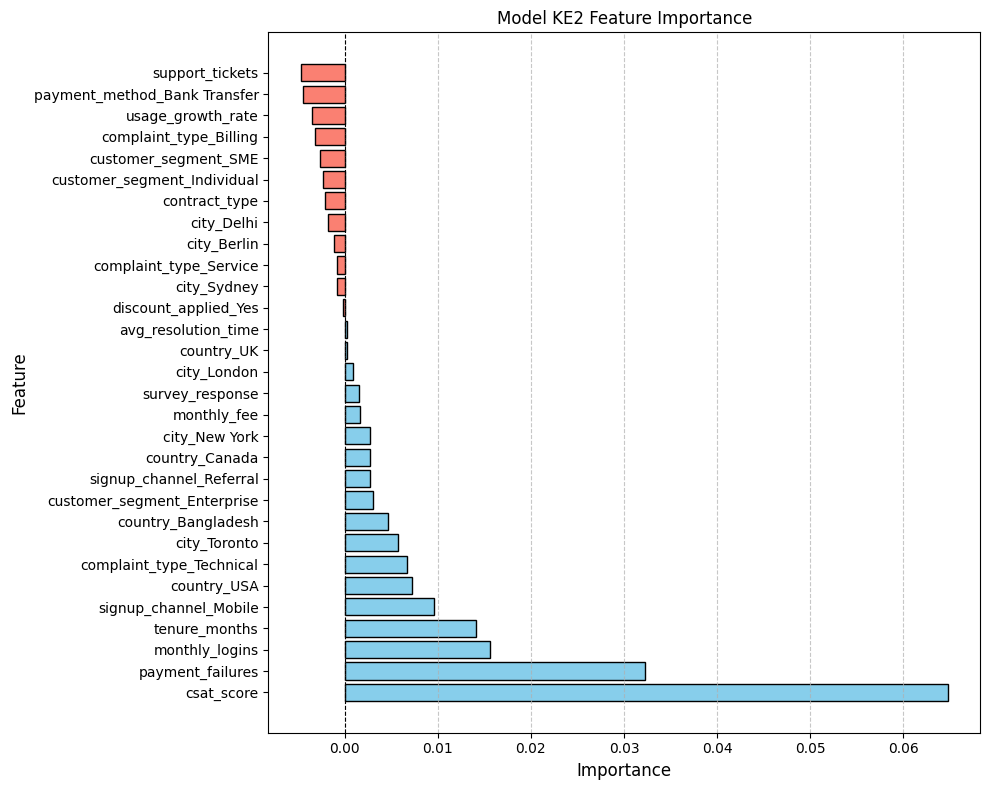

In [ ]:
# Plot the features and importance_means
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in KE2_feature_importance_df['importance']]
plt.barh(KE2_feature_importance_df['feature'], KE2_feature_importance_df['importance'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Model KE2 Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Feature Selection**   
**Model KE3** uses two-stage feature selection.

In [ ]:
# Define neural network
def build_model(meta, learning_rate=0.001):

    input_dim = meta["n_features_in_"]   # input dimension automatically detected

    model = Sequential()

    model.add(Dense(64, activation="relu", input_dim=input_dim))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
# Wrap keras model
from scikeras.wrappers import KerasClassifier
tf.random.set_seed(42)

keras_model = KerasClassifier(
    model=build_model,
    learning_rate=0.001,
    epochs=30,
    batch_size=32,
    verbose=0
)

In [ ]:
# Two stage feature selection
# Stage 1 — tree-based importance
rf_selector = SelectFromModel(
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    max_features=40
)
#Stage 2 — statistical selection
kbest_selector = SelectKBest(
    score_func=mutual_info_classif,
    k=20
)

In [ ]:
# Build pipeline
keras_pipe_KE3 = Pipeline([
    ('preprocessor', preprocessor),
    ('rf_selection', rf_selector),
    ('kbest_selection', kbest_selector),
    ('keras_model', keras_model)
])

In [ ]:
# Train the model
tf.random.set_seed(42)

keras_pipe_KE3.fit(X_train, y_train, keras_model__class_weight=class_weights, keras_model__callbacks=[early_stop])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('rf_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [ ]:
# Set up parameter grid
keras_grid_KE3 = {
    "rf_selection__max_features": [20, 25, 30],
    "kbest_selection__k": [10, 15, 20],
    "keras_model__epochs": [20, 30],
    "keras_model__batch_size": [32, 64],
    "keras_model__learning_rate": [0.0005, 0.001, 0.005]
}

In [ ]:
# Run HalvingRandomSearchCV
tf.random.set_seed(42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_KE3 = HalvingRandomSearchCV(
    keras_pipe_KE3,
    keras_grid_KE3,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
grid_search_KE3.fit(X_train, y_train, keras_model__class_weight=class_weights, keras_model__callbacks=[early_stop])

print(f'Best parameters: {grid_search_KE3.best_params_}')
print(f'Best score: {grid_search_KE3.best_score_:.4f}')

Best parameters: {'rf_selection__max_features': 30, 'keras_model__learning_rate': 0.001, 'keras_model__epochs': 30, 'keras_model__batch_size': 64, 'kbest_selection__k': 10}
Best score: 0.2245


In [ ]:
# Access the optimized pipeline model
grid_search_KE3_opt = grid_search_KE3.best_estimator_
grid_search_KE3_opt

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('rf_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [ ]:
# Accuracy on train and test data
grid_search_KE3_opt_acc_train = grid_search_KE3_opt.score(X_train, y_train)
grid_search_KE3_opt_acc_test = grid_search_KE3_opt.score(X_test, y_test)

print(f'The train accuracy of the model is {grid_search_KE3_opt_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {grid_search_KE3_opt_acc_test*100:.2f}%')

The train accuracy of the model is 78.26%
The test accuracy of the model is 76.01%


In [ ]:
# Generate classification report KE3
y_pred_KE3 = grid_search_KE3_opt.predict(X_test)

print(classification_report(y_test, y_pred_KE3))

              precision    recall  f1-score   support

           0       0.96      0.76      0.85      1439
           1       0.24      0.72      0.36       149

    accuracy                           0.76      1588
   macro avg       0.60      0.74      0.61      1588
weighted avg       0.90      0.76      0.81      1588



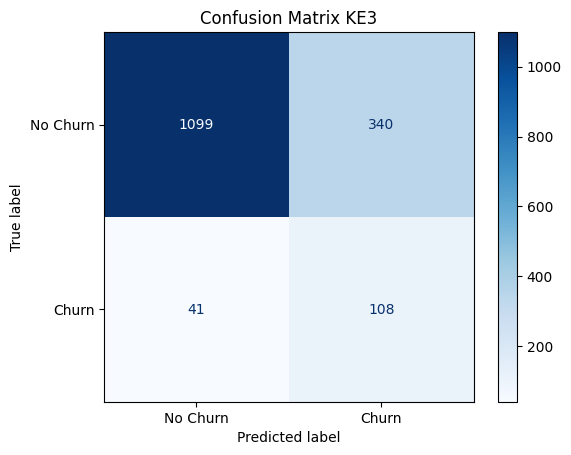

In [ ]:
# Display confusion matrix KE3
conf_matrix_KE3 = confusion_matrix(y_test, y_pred_KE3)
disp_KE3 = ConfusionMatrixDisplay(conf_matrix_KE3, display_labels=['No Churn','Churn'])
disp_KE3.plot(cmap='Blues')
plt.title('Confusion Matrix KE3')
plt.show()

In [ ]:
# Values for false positive (fp_KE3), false negative (fn_KE3), true positive (tp_KE3) and true negative (tn_KE3)
fp_KE3 = conf_matrix_KE3[0][1]
fn_KE3 = conf_matrix_KE3[1][0]
tp_KE3 = conf_matrix_KE3[1][1]
tn_KE3 = conf_matrix_KE3[0][0]

print(f' fp_KE3: {fp_KE3} \n fn_KE3: {fn_KE3} \n tp_KE3: {tp_KE3} \n tn_KE3: {tn_KE3}')

 fp_KE3: 340 
 fn_KE3: 41 
 tp_KE3: 108 
 tn_KE3: 1099


In [ ]:
# Calculations for accuracy, precision, recall
accuracy_KE3 = (tp_KE3 + tn_KE3)/len(y_test)
precision_KE3 = tp_KE3/(tp_KE3 + fp_KE3)
recall_KE3 = tp_KE3/(tp_KE3 + fn_KE3)

print(f'Accuracy: {accuracy_KE3:.2f}')
print(f'Precision: {precision_KE3:.2f}')
print(f'Recall: {recall_KE3:.2f}')
print(f'-'*15)

Accuracy: 0.76
Precision: 0.24
Recall: 0.72
---------------


In [ ]:
# Calculate F2 score
beta = 2
F2_score_KE3 = (1 + beta**2) * (precision_KE3 * recall_KE3) / (beta**2 * precision_KE3 + recall_KE3)

print(f'The F2 score is {F2_score_KE3:.4f}')

The F2 score is 0.5172


In [ ]:
# Profit/loss analysis
Profit_Loss_KE3 = tp_KE3*(L - C) - fp_KE3*C - fn_KE3*L

print(f'The profit or loss is ${Profit_Loss_KE3}')

The profit or loss is $15580


**ROC Curve**    
The ROC Curve is plotted and the optimum threshold is obtained.

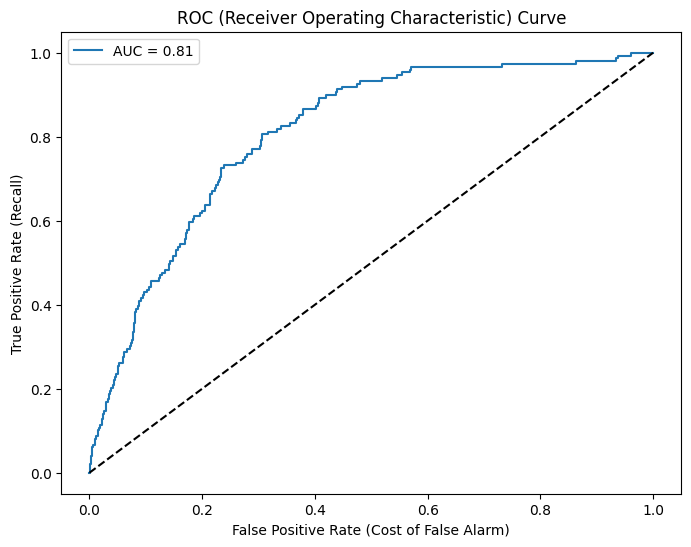

In [ ]:
# Plot the ROC Curve
y_probs_KE3 = grid_search_KE3_opt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_KE3)
auc_KE3 = round(roc_auc_score(y_test, y_probs_KE3), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs_KE3):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [ ]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_KE3 = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold_KE3 :.4f}')

The optimal threshold is 0.4050


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve

In [ ]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_KE3)
avg_precision = average_precision_score(y_test, y_probs_KE3)

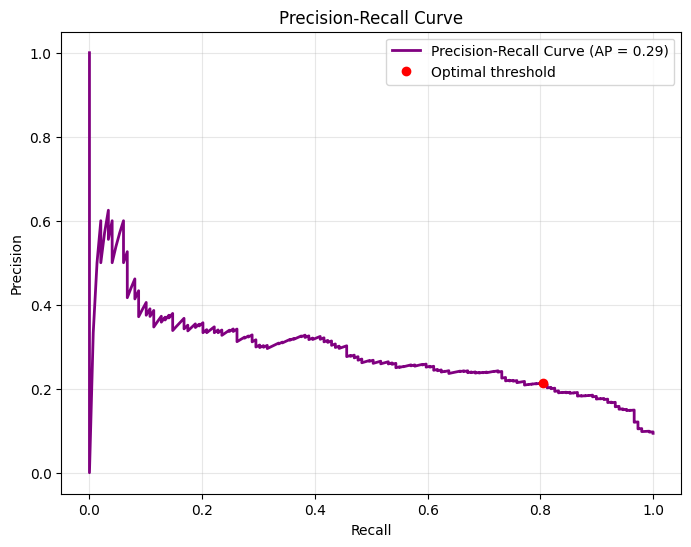

In [ ]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold_KE3))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [ ]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0.05, 0.80, 0.05)
for threshold in thresholds:
    preds = (y_probs_KE3 >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.05 | Precision=0.10 | Recall=0.98
Threshold=0.10 | Precision=0.12 | Recall=0.97
Threshold=0.15 | Precision=0.14 | Recall=0.97
Threshold=0.20 | Precision=0.16 | Recall=0.93
Threshold=0.25 | Precision=0.17 | Recall=0.92
Threshold=0.30 | Precision=0.18 | Recall=0.87
Threshold=0.35 | Precision=0.19 | Recall=0.83
Threshold=0.40 | Precision=0.21 | Recall=0.81
Threshold=0.45 | Precision=0.22 | Recall=0.75
Threshold=0.50 | Precision=0.24 | Recall=0.72
Threshold=0.55 | Precision=0.24 | Recall=0.62
Threshold=0.60 | Precision=0.25 | Recall=0.57
Threshold=0.65 | Precision=0.27 | Recall=0.50
Threshold=0.70 | Precision=0.30 | Recall=0.44
Threshold=0.75 | Precision=0.32 | Recall=0.38


In [ ]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs_KE3 >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.25


In [ ]:
# Define Model KE3 threshold
threshold_KE3 = best_threshold

In [ ]:
# Use the threshold that maximizes profit
y_pred_KE3 = (y_probs_KE3 >= threshold_KE3).astype(int)

In [ ]:
# Generate classification report KE3

print(classification_report(y_test, y_pred_KE3))

              precision    recall  f1-score   support

           0       0.98      0.55      0.70      1439
           1       0.17      0.92      0.29       149

    accuracy                           0.58      1588
   macro avg       0.58      0.73      0.50      1588
weighted avg       0.91      0.58      0.66      1588



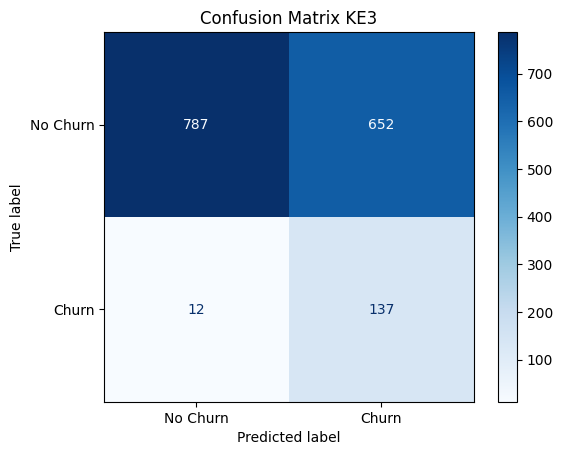

In [ ]:
# Display confusion matrix KE3
conf_matrix_KE3 = confusion_matrix(y_test, y_pred_KE3)
disp_KE3 = ConfusionMatrixDisplay(conf_matrix_KE3, display_labels=['No Churn','Churn'])
disp_KE3.plot(cmap='Blues')
plt.title('Confusion Matrix KE3')
plt.show()

In [ ]:
# Values for false positive (fp_KE3), false negative (fn_KE3), true positive (tp_KE3) and true negative (tn_KE3)
fp_KE3 = conf_matrix_KE3[0][1]
fn_KE3 = conf_matrix_KE3[1][0]
tp_KE3 = conf_matrix_KE3[1][1]
tn_KE3 = conf_matrix_KE3[0][0]

print(f' fp_KE3: {fp_KE3} \n fn_KE3: {fn_KE3} \n tp_KE3: {tp_KE3} \n tn_KE3: {tn_KE3}')

 fp_KE3: 652 
 fn_KE3: 12 
 tp_KE3: 137 
 tn_KE3: 787


In [ ]:
# Calculations for accuracy, precision, recall
accuracy_KE3 = (tp_KE3 + tn_KE3)/len(y_test)
precision_KE3 = tp_KE3/(tp_KE3 + fp_KE3)
recall_KE3 = tp_KE3/(tp_KE3 + fn_KE3)

print(f'Accuracy: {accuracy_KE3:.2f}')
print(f'Precision: {precision_KE3:.2f}')
print(f'Recall: {recall_KE3:.2f}')
print(f'-'*15)

Accuracy: 0.58
Precision: 0.17
Recall: 0.92
---------------


In [ ]:
# Calculate F2 score
beta = 2
F2_score_KE3 = (1 + beta**2) * (precision_KE3 * recall_KE3) / (beta**2 * precision_KE3 + recall_KE3)

print(f'The F2 score is {F2_score_KE3:.4f}')

The F2 score is 0.4946


In [ ]:
# Profit/loss analysis
Profit_Loss_KE3 = tp_KE3*(L - C) - fp_KE3*C - fn_KE3*L

print(f'The profit or loss is ${Profit_Loss_KE3}')

The profit or loss is $30940


**Feature Importance Model KE3**          
The model finds the features **tenure_months**, **tenure_fee_interaction**, **csat_score**, and **payment_failures** to be highly important.


In [ ]:
# Extract final selected features
rf_step = grid_search_KE3_opt.named_steps['rf_selection']
kbest_step = grid_search_KE3_opt.named_steps['kbest_selection']

feature_names = grid_search_KE3_opt.named_steps['preprocessor'].get_feature_names_out()
feature_names = [i.split('__')[-1] for i in feature_names]  # Clean feature names

feature_names = pd.Series(feature_names)
rf_features = feature_names[rf_step.get_support()]
final_features = rf_features[kbest_step.get_support()]

print(final_features)

1              tenure_months
2             monthly_logins
4           avg_session_time
8                monthly_fee
9           payment_failures
11       avg_resolution_time
12                csat_score
14           email_open_rate
15      marketing_click_rate
18    tenure_fee_interaction
dtype: object


In [ ]:
# Random Forest importances
rf_model = rf_step.estimator_
rf_importances = rf_model.feature_importances_

rf_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_importances
}).sort_values("importance", ascending=False)

print(rf_importance_df.head())

                   feature  importance
1            tenure_months    0.078914
2           monthly_logins    0.070158
18  tenure_fee_interaction    0.064267
12              csat_score    0.055069
4         avg_session_time    0.052330


In [ ]:
# Random Forest importances of only selected features
rf_selected_importance_df = pd.DataFrame({
    "feature": rf_features,
    "importance": rf_model.feature_importances_[rf_step.get_support()]
}).sort_values("importance", ascending=False)

print(rf_selected_importance_df.head())

                   feature  importance
1            tenure_months    0.078914
2           monthly_logins    0.070158
18  tenure_fee_interaction    0.064267
12              csat_score    0.055069
4         avg_session_time    0.052330


In [ ]:
# SelectKBest feature scores
kbest_scores = kbest_step.scores_

kbest_importance_df = pd.DataFrame({
    "feature": rf_features,
    "score": kbest_scores
}).sort_values("score", ascending=False)

In [ ]:
# Final features with scores
KE3_feature_importance_df = pd.DataFrame({
    "feature": final_features,
    "score": kbest_scores[kbest_step.get_support()]
}).sort_values("score", ascending=False)

In [ ]:
# Reset index
KE3_feature_importance_df = KE3_feature_importance_df.reset_index(drop=True)
KE3_feature_importance_df.index = KE3_feature_importance_df.index + 1
KE3_feature_importance_df.index.name = "Rank"

KE3_feature_importance_df.head(10)

,feature,score
Rank,,
1,tenure_months,0.028713
2,tenure_fee_interaction,0.016540
3,csat_score,0.016110
4,monthly_logins,0.011678
5,payment_failures,0.006291
6,monthly_fee,0.002829
7,marketing_click_rate,0.002651
8,email_open_rate,0.002518
9,avg_session_time,0.001828


In [ ]:
# Select the first twenty features
KE3_feature_importance_df = KE3_feature_importance_df.iloc[:20]

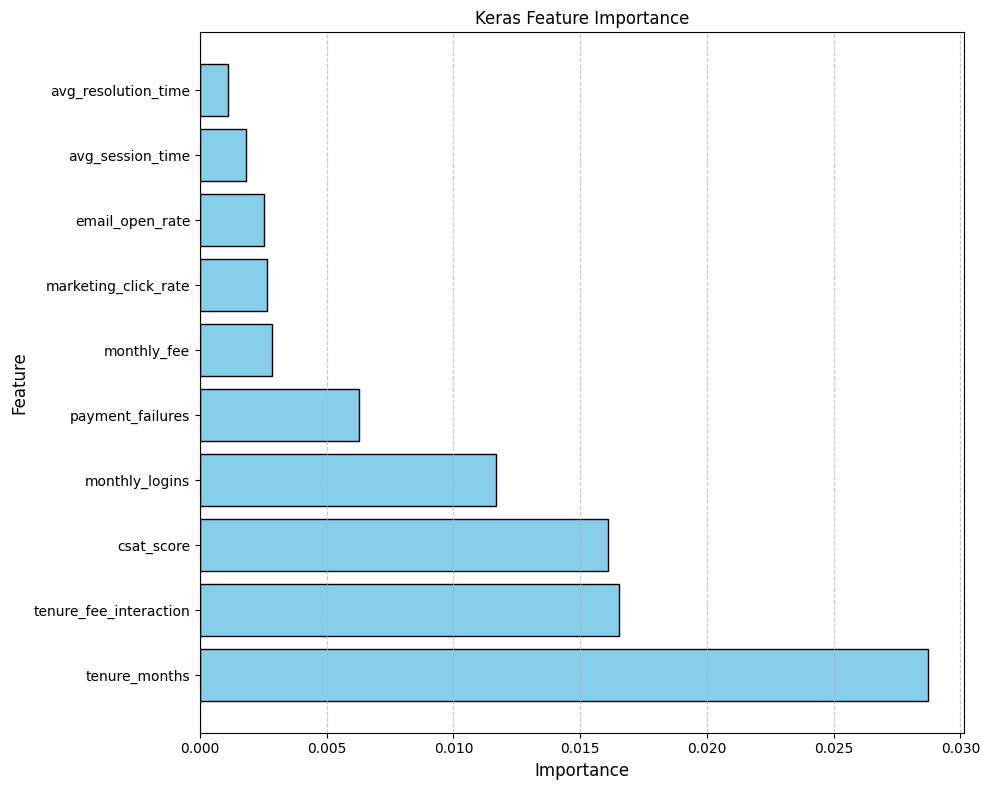

In [ ]:
# Plot the important features and importance_means
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in KE3_feature_importance_df['score']]
plt.barh(KE3_feature_importance_df['feature'], KE3_feature_importance_df['score'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Keras Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Feature Selection**   
**Model KE4** uses Random Forest only for feature selection.

In [ ]:
# Obtain the best number of features based on AUC
auc=[]
features = np.arange(22, 28, 2)
for i in features:
  tf.random.set_seed(42)
  # Wrap keras model
  keras_model = KerasClassifier(
      model=build_model,
      learning_rate=0.001,
      epochs=50,
      batch_size=32,
      verbose=0
  )
  # Feature selection
  rf_selector = SelectFromModel(
      RandomForestClassifier(
          n_estimators=200,
          random_state=42
      ),
      max_features=i
  )
  # Build pipeline
  keras_pipe = Pipeline([
      ('preprocessor', preprocessor),
      ('rf_selection', rf_selector),
      ('keras_model', keras_model)
  ])
  # Train the model
  keras_pipe.fit(X_train, y_train, keras_model__class_weight=class_weights, keras_model__callbacks=[early_stop])
  # Set up parameter grid
  keras_grid = {
      "rf_selection__max_features": [20, 25, 30],
      "keras_model__epochs": [20, 30],
      "keras_model__batch_size": [32, 64],
      "keras_model__learning_rate": [0.0005, 0.001, 0.005]
  }
  # Run HalvingRandomSearchCV
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  grid_search = HalvingRandomSearchCV(
      keras_pipe,
      keras_grid,
      scoring="f1",
      cv=cv,
      n_jobs=-1
  )
  grid_search.fit(X_train, y_train, keras_model__class_weight=class_weights, keras_model__callbacks=[early_stop])
  # Access the optimized pipeline model
  grid_search_opt = grid_search.best_estimator_
  # Evaluate 'roc_auc_score'
  y_proba = grid_search_opt.predict_proba(X_test)[:, 1]
  roc_auc = roc_auc_score(y_test, y_proba)
  auc.append(roc_auc)
  print(f'Number of Features = {i} | AUC = {roc_auc:.4f}')

Number of Features = 22 | AUC = 0.7796
Number of Features = 24 | AUC = 0.7496
Number of Features = 26 | AUC = 0.7751


In [ ]:
# Determine best number of features
best_features = features[np.argmax(auc)]

print(f'The best number of features is {best_features}.')

The best number of features is 22.


In [ ]:
# Wrap keras model
tf.random.set_seed(42)

keras_model_KE4 = KerasClassifier(
    model=build_model,
    learning_rate=0.001,
    epochs=50,
    batch_size=32,
    verbose=0
)

In [ ]:
# Feature selection
rf_selector = SelectFromModel(
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    max_features=best_features
)

In [ ]:
# Build pipeline
tf.random.set_seed(42)

keras_pipe_KE4 = Pipeline([
    ('preprocessor', preprocessor),
    ('rf_selection', rf_selector),
    ('keras_model', keras_model)
])
keras_pipe_KE4.fit(X_train, y_train, keras_model__class_weight=class_weights, keras_model__callbacks=[early_stop])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('rf_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [ ]:
# Set up parameter grid
keras_grid_KE4 = {
    "rf_selection__max_features": [20, 25, 30],
    "keras_model__epochs": [20, 30],
    "keras_model__batch_size": [32, 64],
    "keras_model__learning_rate": [0.0005, 0.001, 0.005]
}

In [ ]:
# Run HalvingRandomSearchCV
tf.random.set_seed(42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_KE4 = HalvingRandomSearchCV(
    keras_pipe_KE4,
    keras_grid_KE4,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
grid_search_KE4.fit(X_train, y_train, keras_model__class_weight=class_weights, keras_model__callbacks=[early_stop])

print(f'Best parameters: {grid_search_KE4.best_params_}')
print(f'Best score: {grid_search_KE4.best_score_:.4f}')

Best parameters: {'rf_selection__max_features': 25, 'keras_model__learning_rate': 0.0005, 'keras_model__epochs': 30, 'keras_model__batch_size': 32}
Best score: 0.2358


In [ ]:
# Access the optimized pipeline model
grid_search_KE4_opt = grid_search_KE4.best_estimator_

In [ ]:
# Accuracy on train and test data
grid_search_KE4_opt_acc_train = grid_search_KE4_opt.score(X_train, y_train)
grid_search_KE4_opt_acc_test = grid_search_KE4_opt.score(X_test, y_test)

print(f'The train accuracy of the model is {grid_search_KE4_opt_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {grid_search_KE4_opt_acc_test*100:.2f}%')

The train accuracy of the model is 80.52%
The test accuracy of the model is 74.62%


In [ ]:
# Generate classification report R4
y_pred_KE4 = grid_search_KE4_opt.predict(X_test)

print(classification_report(y_test, y_pred_KE4))

              precision    recall  f1-score   support

           0       0.95      0.76      0.84      1439
           1       0.21      0.61      0.31       149

    accuracy                           0.75      1588
   macro avg       0.58      0.69      0.58      1588
weighted avg       0.88      0.75      0.79      1588



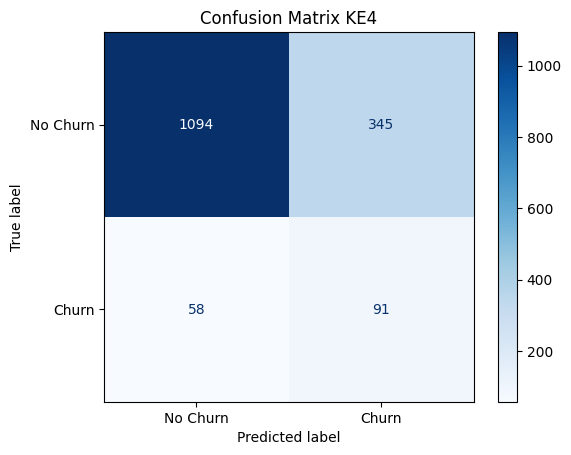

In [ ]:
# Display confusion matrix KE4
conf_matrix_KE4 = confusion_matrix(y_test, y_pred_KE4)
disp_KE4 = ConfusionMatrixDisplay(conf_matrix_KE4, display_labels=['No Churn','Churn'])
disp_KE4.plot(cmap='Blues')
plt.title('Confusion Matrix KE4')
plt.show()

In [ ]:
# Values for false positive (fp_KE4), false negative (fn_KE4), true positive (tp_KE4) and true negative (tn_KE4)
fp_KE4 = conf_matrix_KE4[0][1]
fn_KE4 = conf_matrix_KE4[1][0]
tp_KE4 = conf_matrix_KE4[1][1]
tn_KE4 = conf_matrix_KE4[0][0]

print(f' fp_KE4: {fp_KE4} \n fn_KE4: {fn_KE4} \n tp_KE4: {tp_KE4} \n tn_KE4: {tn_KE4}')

 fp_KE4: 345 
 fn_KE4: 58 
 tp_KE4: 91 
 tn_KE4: 1094


In [ ]:
# Calculations for accuracy, precision, recall
accuracy_KE4 = (tp_KE4 + tn_KE4)/len(y_test)
precision_KE4 = tp_KE4/(tp_KE4 + fp_KE4)
recall_KE4 = tp_KE4/(tp_KE4 + fn_KE4)

print(f'Accuracy: {accuracy_KE4:.2f}')
print(f'Precision: {precision_KE4:.2f}')
print(f'Recall: {recall_KE4:.2f}')
print(f'-'*15)

Accuracy: 0.75
Precision: 0.21
Recall: 0.61
---------------


In [ ]:
# Calculate F2 score
beta = 2
F2_score_KE4 = (1 + beta**2) * (precision_KE4 * recall_KE4) / (beta**2 * precision_KE4 + recall_KE4)

print(f'The F2 score is {F2_score_KE4:.4f}')

The F2 score is 0.4409


In [ ]:
# Profit/loss analysis
Profit_Loss_KE4 = tp_KE4*(L - C) - fp_KE4*C - fn_KE4*L

print(f'The profit or loss is ${Profit_Loss_KE4}')

The profit or loss is $-940


**ROC Curve**    
The ROC Curve is plotted and the optimum threshold is obtained.

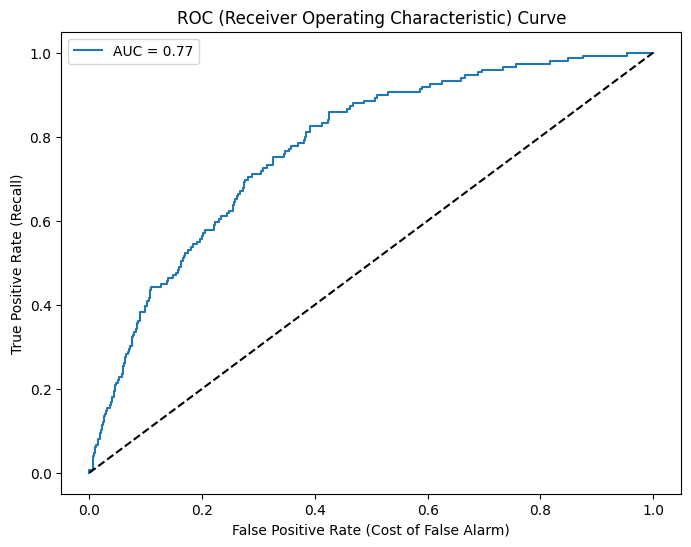

In [ ]:
# Plot the ROC Curve
y_probs_KE4 = grid_search_KE4_opt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_KE4)
auc_KE4 = round(roc_auc_score(y_test, y_probs_KE4), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs_KE4):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [ ]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_KE4 = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold_KE4 :.4f}')

The optimal threshold is 0.3005


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve

In [ ]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_KE4)
avg_precision = average_precision_score(y_test, y_probs_KE4)

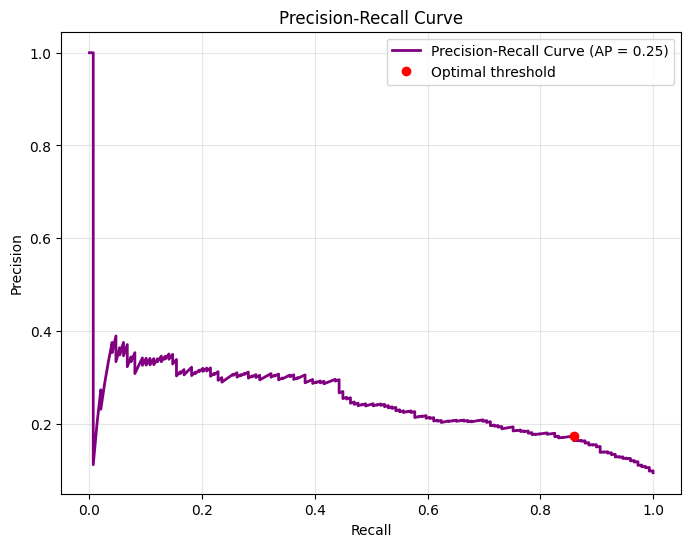

In [ ]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold_KE4))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [ ]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0.05, 0.80, 0.05)
for threshold in thresholds:
    preds = (y_probs_KE4 >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.05 | Precision=0.10 | Recall=0.99
Threshold=0.10 | Precision=0.12 | Recall=0.97
Threshold=0.15 | Precision=0.13 | Recall=0.93
Threshold=0.20 | Precision=0.14 | Recall=0.91
Threshold=0.25 | Precision=0.16 | Recall=0.89
Threshold=0.30 | Precision=0.17 | Recall=0.86
Threshold=0.35 | Precision=0.18 | Recall=0.78
Threshold=0.40 | Precision=0.19 | Recall=0.73
Threshold=0.45 | Precision=0.21 | Recall=0.70
Threshold=0.50 | Precision=0.21 | Recall=0.61
Threshold=0.55 | Precision=0.22 | Recall=0.58
Threshold=0.60 | Precision=0.24 | Recall=0.52
Threshold=0.65 | Precision=0.25 | Recall=0.46
Threshold=0.70 | Precision=0.29 | Recall=0.44
Threshold=0.75 | Precision=0.30 | Recall=0.34


In [ ]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs_KE4 >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.3


In [ ]:
# Define Model KE4 threshold
threshold_KE4 = best_threshold

In [ ]:
# Use the threshold that maximizes profit
y_pred_KE4 = (y_probs_KE4 >= best_threshold).astype(int)

In [ ]:
# Generate classification report KE4

print(classification_report(y_test, y_pred_KE4))

              precision    recall  f1-score   support

           0       0.98      0.57      0.72      1439
           1       0.17      0.86      0.29       149

    accuracy                           0.60      1588
   macro avg       0.57      0.72      0.51      1588
weighted avg       0.90      0.60      0.68      1588



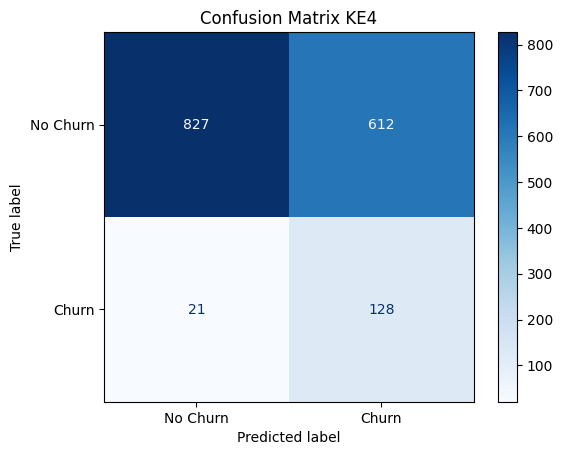

In [ ]:
# Display confusion matrix KE4
conf_matrix_KE4 = confusion_matrix(y_test, y_pred_KE4)
disp_KE4 = ConfusionMatrixDisplay(conf_matrix_KE4, display_labels=['No Churn','Churn'])
disp_KE4.plot(cmap='Blues')
plt.title('Confusion Matrix KE4')
plt.show()

In [ ]:
# Values for false positive (fp_KE4), false negative (fn_KE4), true positive (tp_KE4) and true negative (tn_KE4)
fp_KE4 = conf_matrix_KE4[0][1]
fn_KE4 = conf_matrix_KE4[1][0]
tp_KE4 = conf_matrix_KE4[1][1]
tn_KE4 = conf_matrix_KE4[0][0]

print(f' fp_KE4: {fp_KE4} \n fn_KE4: {fn_KE4} \n tp_KE4: {tp_KE4} \n tn_KE4: {tn_KE4}')

 fp_KE4: 612 
 fn_KE4: 21 
 tp_KE4: 128 
 tn_KE4: 827


In [ ]:
# Calculations for accuracy, precision, recall
accuracy_KE4 = (tp_KE4 + tn_KE4)/len(y_test)
precision_KE4 = tp_KE4/(tp_KE4 + fp_KE4)
recall_KE4 = tp_KE4/(tp_KE4 + fn_KE4)

print(f'Accuracy: {accuracy_KE4:.2f}')
print(f'Precision: {precision_KE4:.2f}')
print(f'Recall: {recall_KE4:.2f}')
print(f'-'*15)

Accuracy: 0.60
Precision: 0.17
Recall: 0.86
---------------


In [ ]:
# Calculate F2 score
beta = 2
F2_score_KE4 = (1 + beta**2) * (precision_KE4 * recall_KE4) / (beta**2 * precision_KE4 + recall_KE4)

print(f'The F2 score is {F2_score_KE4:.4f}')

The F2 score is 0.4790


In [ ]:
# Profit/loss analysis
Profit_Loss_KE4 = tp_KE4*(L - C) - fp_KE4*C - fn_KE4*L

print(f'The profit or loss is ${Profit_Loss_KE4}')

The profit or loss is $23900


**Feature Importance Model KE4**          
The model finds the features **tenure_months**, **monthly_logins**, **tenure_fee_interaction**, and **csat_score** to be highly important.


In [ ]:
# Extract selected features
rf_step = grid_search_KE4_opt.named_steps['rf_selection']

feature_names = grid_search_KE4_opt.named_steps['preprocessor'].get_feature_names_out()
feature_names = [i.split('__')[-1] for i in feature_names]  # Clean feature names

feature_names = pd.Series(feature_names)
selected_features = feature_names[rf_step.get_support()]

print(selected_features)

0                        age
1              tenure_months
2             monthly_logins
3         weekly_active_days
4           avg_session_time
5              features_used
6          usage_growth_rate
7        last_login_days_ago
8                monthly_fee
9           payment_failures
11       avg_resolution_time
12                csat_score
14           email_open_rate
15      marketing_click_rate
16                 nps_score
18    tenure_fee_interaction
dtype: object


In [ ]:
# Random Forest importances
rf_model = rf_step.estimator_
rf_importances = rf_model.feature_importances_

rf_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_importances
}).sort_values("importance", ascending=False)

print(rf_importance_df.head())

                   feature  importance
1            tenure_months    0.078914
2           monthly_logins    0.070158
18  tenure_fee_interaction    0.064267
12              csat_score    0.055069
4         avg_session_time    0.052330


In [ ]:
# Importances of selected features
KE4_feature_importance_df = pd.DataFrame({
    "feature": selected_features,
    "importance": rf_model.feature_importances_[rf_step.get_support()]
}).sort_values("importance", ascending=False)

print(KE4_feature_importance_df.head())

                   feature  importance
1            tenure_months    0.078914
2           monthly_logins    0.070158
18  tenure_fee_interaction    0.064267
12              csat_score    0.055069
4         avg_session_time    0.052330


In [ ]:
# Reset index
KE4_feature_importance_df = KE4_feature_importance_df.reset_index(drop=True)
KE4_feature_importance_df.index = KE4_feature_importance_df.index + 1
KE4_feature_importance_df.index.name = "Rank"

KE4_feature_importance_df.head(10)

,feature,importance
Rank,,
1,tenure_months,0.078914
2,monthly_logins,0.070158
3,tenure_fee_interaction,0.064267
4,csat_score,0.055069
5,avg_session_time,0.052330
6,avg_resolution_time,0.051666
7,usage_growth_rate,0.047269
8,nps_score,0.046533
9,marketing_click_rate,0.044551


In [ ]:
# Select the first twenty features
KE4_feature_importance_df = KE4_feature_importance_df.iloc[:20]

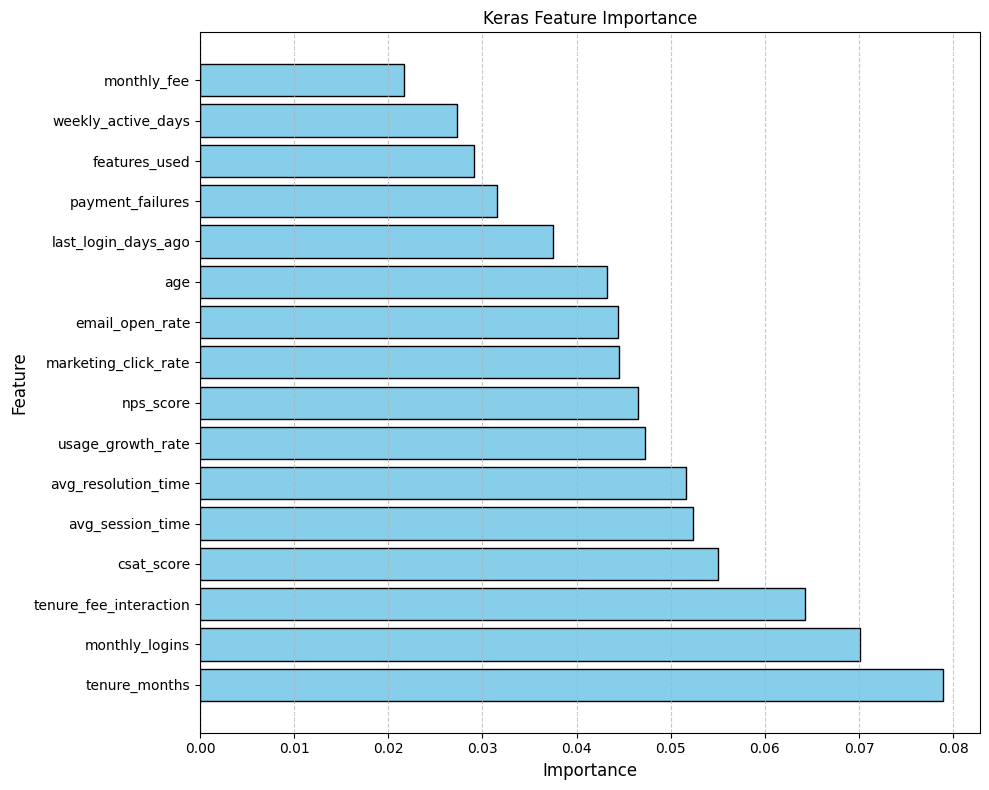

In [ ]:
# Plot the important features and importance_means
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in KE4_feature_importance_df['importance']]
plt.barh(KE4_feature_importance_df['feature'], KE4_feature_importance_df['importance'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Keras Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Feature Selection**   
**Model KE5** uses SelectKBest only for feature selection.

In [ ]:
# Obtain the best number of features based on AUC
auc=[]
features = np.arange(16, 22, 2)
for i in features:
  tf.random.set_seed(42)
  # Wrap keras model
  keras_model = KerasClassifier(
      model=build_model,
      learning_rate=0.001,
      epochs=50,
      batch_size=32,
      verbose=0
  )
  # Feature selection
  kbest_selector = SelectKBest(
      score_func=mutual_info_classif,
      k=i
  )
  # Build pipeline
  keras_pipe = Pipeline([
      ('preprocessor', preprocessor),
      ('kbest_selection', kbest_selector),
      ('keras_model', keras_model)
  ])
  # Train the model
  keras_pipe.fit(X_train, y_train, keras_model__class_weight=class_weights, keras_model__callbacks=[early_stop])
  # Set up parameter grid
  keras_grid = {
      "kbest_selection__k": [10, 15, 20],
      "keras_model__epochs": [20, 30],
      "keras_model__batch_size": [32, 64],
      "keras_model__learning_rate": [0.0005, 0.001, 0.005]
  }
  # Run HalvingRandomSearchCV
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  grid_search = HalvingRandomSearchCV(
      keras_pipe,
      keras_grid,
      scoring="f1",
      cv=cv,
      n_jobs=-1
  )
  grid_search.fit(X_train, y_train, keras_model__class_weight=class_weights, keras_model__callbacks=[early_stop])
  # Access the optimized pipeline model
  grid_search_opt = grid_search.best_estimator_
  # Evaluate 'roc_auc_score'
  y_proba = grid_search_opt.predict_proba(X_test)[:, 1]
  roc_auc = roc_auc_score(y_test, y_proba)
  auc.append(roc_auc)
  print(f'Number of Features = {i} | AUC = {roc_auc:.4f}')

Number of Features = 16 | AUC = 0.7610
Number of Features = 18 | AUC = 0.8237
Number of Features = 20 | AUC = 0.8301


In [ ]:
# Determine best number of features
best_features = features[np.argmax(auc)]

print(f'The best number of features is {best_features}.')

The best number of features is 20.


In [ ]:
# Wrap keras model
tf.random.set_seed(42)

keras_model_KE5 = KerasClassifier(
    model=build_model,
    learning_rate=0.001,
    epochs=50,
    batch_size=32,
    verbose=0
)

In [ ]:
# Feature selection
kbest_selector = SelectKBest(
    score_func=mutual_info_classif,
    k=best_features
)

In [ ]:
# Build pipeline
tf.random.set_seed(42)

keras_pipe_KE5 = Pipeline([
    ('preprocessor', preprocessor),
    ('kbest_selection', kbest_selector),
    ('keras_model', keras_model)
])
keras_pipe_KE5.fit(X_train, y_train, keras_model__class_weight=class_weights, keras_model__callbacks=[early_stop])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('kbest_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [ ]:
# Set up parameter grid
keras_grid_KE5 = {
    "kbest_selection__k": [10, 15, 20],
    "keras_model__epochs": [20, 30],
    "keras_model__batch_size": [32, 64],
    "keras_model__learning_rate": [0.0005, 0.001, 0.005]
}

In [ ]:
# Run HalvingRandomSearchCV
tf.random.set_seed(42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_KE5 = HalvingRandomSearchCV(
    keras_pipe_KE5,
    keras_grid_KE5,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
grid_search_KE5.fit(X_train, y_train, keras_model__class_weight=class_weights, keras_model__callbacks=[early_stop])

print(f'Best parameters: {grid_search_KE5.best_params_}')
print(f'Best score: {grid_search_KE5.best_score_:.4f}')

Best parameters: {'keras_model__learning_rate': 0.0005, 'keras_model__epochs': 20, 'keras_model__batch_size': 64, 'kbest_selection__k': 10}
Best score: 0.1569


In [ ]:
# Access the optimized pipeline model
grid_search_KE5_opt = grid_search_KE5.best_estimator_

In [ ]:
# Accuracy on train and test data
grid_search_KE5_opt_acc_train = grid_search_KE5_opt.score(X_train, y_train)
grid_search_KE5_opt_acc_test = grid_search_KE5_opt.score(X_test, y_test)

print(f'The train accuracy of the model is {grid_search_KE5_opt_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {grid_search_KE5_opt_acc_test*100:.2f}%')

The train accuracy of the model is 71.33%
The test accuracy of the model is 69.08%


In [ ]:
# Generate classification report KE5
y_pred_KE5 = grid_search_KE5_opt.predict(X_test)

print(classification_report(y_test, y_pred_KE5))

              precision    recall  f1-score   support

           0       0.98      0.67      0.80      1439
           1       0.21      0.86      0.34       149

    accuracy                           0.69      1588
   macro avg       0.60      0.77      0.57      1588
weighted avg       0.91      0.69      0.76      1588



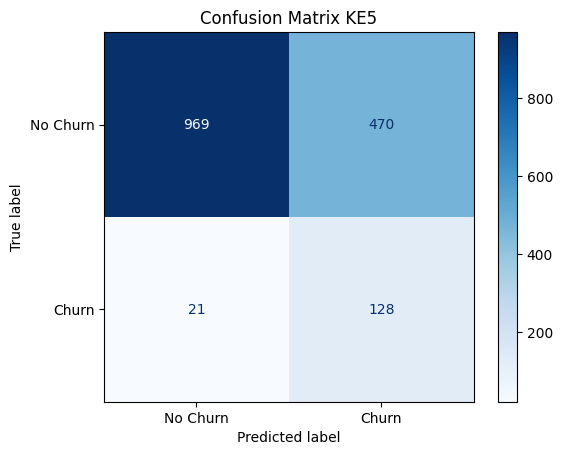

In [ ]:
# Display confusion matrix KE5
conf_matrix_KE5 = confusion_matrix(y_test, y_pred_KE5)
disp_KE5 = ConfusionMatrixDisplay(conf_matrix_KE5, display_labels=['No Churn','Churn'])
disp_KE5.plot(cmap='Blues')
plt.title('Confusion Matrix KE5')
plt.show()

In [ ]:
# Values for false positive (fp_KE5), false negative (fn_KE5), true positive (tp_KE5) and true negative (tn_KE5)
fp_KE5 = conf_matrix_KE5[0][1]
fn_KE5 = conf_matrix_KE5[1][0]
tp_KE5 = conf_matrix_KE5[1][1]
tn_KE5 = conf_matrix_KE5[0][0]

print(f' fp_KE5: {fp_KE5} \n fn_KE5: {fn_KE5} \n tp_KE5: {tp_KE5} \n tn_KE5: {tn_KE5}')

 fp_KE5: 470 
 fn_KE5: 21 
 tp_KE5: 128 
 tn_KE5: 969


In [ ]:
# Calculations for accuracy, precision, recall
accuracy_KE5 = (tp_KE5 + tn_KE5)/len(y_test)
precision_KE5 = tp_KE5/(tp_KE5 + fp_KE5)
recall_KE5 = tp_KE5/(tp_KE5 + fn_KE5)

print(f'Accuracy: {accuracy_KE5:.2f}')
print(f'Precision: {precision_KE5:.2f}')
print(f'Recall: {recall_KE5:.2f}')
print(f'-'*15)

Accuracy: 0.69
Precision: 0.21
Recall: 0.86
---------------


In [ ]:
# Calculate F2 score
beta = 2
F2_score_KE5 = (1 + beta**2) * (precision_KE5 * recall_KE5) / (beta**2 * precision_KE5 + recall_KE5)

print(f'The F2 score is {F2_score_KE5:.4f}')

The F2 score is 0.5360


In [ ]:
# Profit/loss analysis
Profit_Loss_KE5 = tp_KE5*(L - C) - fp_KE5*C - fn_KE5*L

print(f'The profit or loss is ${Profit_Loss_KE5}')

The profit or loss is $29580


**ROC Curve**    
The ROC Curve is plotted and the optimum threshold is obtained.

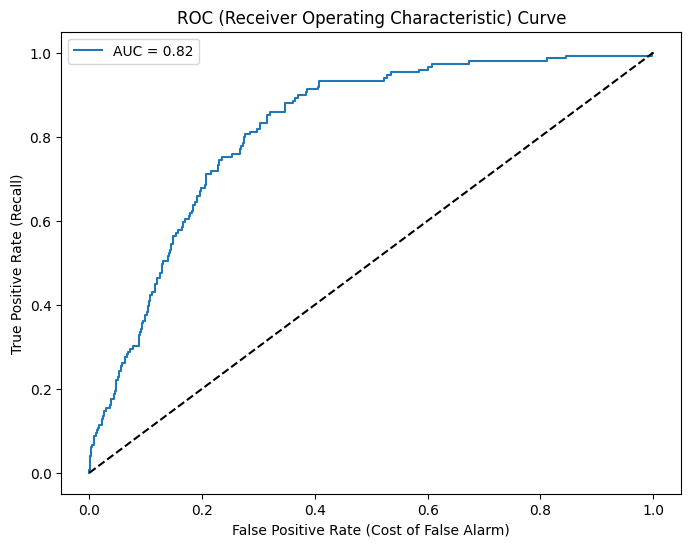

In [ ]:
# Plot the ROC Curve
y_probs_KE5 = grid_search_KE5_opt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_KE5)
auc_KE5 = round(roc_auc_score(y_test, y_probs_KE5), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs_KE5):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [ ]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_KE5 = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold_KE5 :.4f}')

The optimal threshold is 0.5077


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve

In [ ]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_KE5)
avg_precision = average_precision_score(y_test, y_probs_KE5)

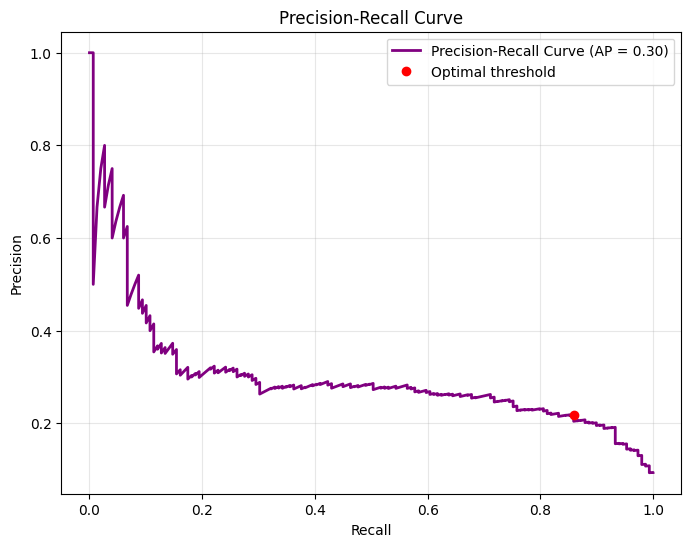

In [ ]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold_KE5))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [ ]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0.05, 0.80, 0.05)
for threshold in thresholds:
    preds = (y_probs_KE5 >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.05 | Precision=0.09 | Recall=0.99
Threshold=0.10 | Precision=0.10 | Recall=0.99
Threshold=0.15 | Precision=0.11 | Recall=0.98
Threshold=0.20 | Precision=0.13 | Recall=0.98
Threshold=0.25 | Precision=0.14 | Recall=0.97
Threshold=0.30 | Precision=0.15 | Recall=0.95
Threshold=0.35 | Precision=0.17 | Recall=0.93
Threshold=0.40 | Precision=0.19 | Recall=0.93
Threshold=0.45 | Precision=0.20 | Recall=0.90
Threshold=0.50 | Precision=0.21 | Recall=0.86
Threshold=0.55 | Precision=0.23 | Recall=0.79
Threshold=0.60 | Precision=0.25 | Recall=0.72
Threshold=0.65 | Precision=0.26 | Recall=0.61
Threshold=0.70 | Precision=0.28 | Recall=0.48
Threshold=0.75 | Precision=0.28 | Recall=0.34


In [ ]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs_KE5 >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.4


In [ ]:
# Define Model KE5 threshold
threshold_KE5 = best_threshold

In [ ]:
# Use the threshold that maximizes profit
y_pred_KE5 = (y_probs_KE5 >= best_threshold).astype(int)

In [ ]:
# Generate classification report KE5

print(classification_report(y_test, y_pred_KE5))

              precision    recall  f1-score   support

           0       0.99      0.58      0.73      1439
           1       0.19      0.93      0.31       149

    accuracy                           0.61      1588
   macro avg       0.59      0.76      0.52      1588
weighted avg       0.91      0.61      0.69      1588



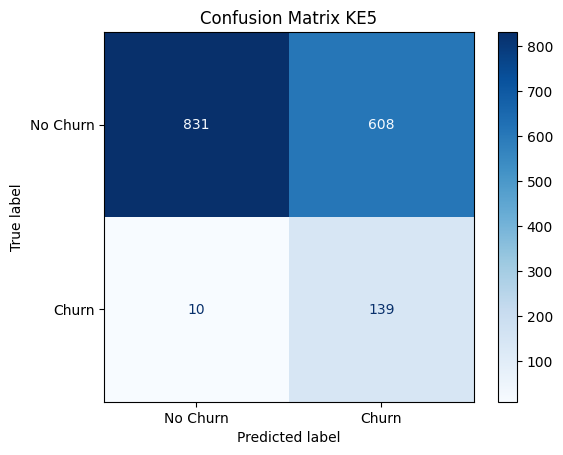

In [ ]:
# Display confusion matrix KE5
conf_matrix_KE5 = confusion_matrix(y_test, y_pred_KE5)
disp_KE5 = ConfusionMatrixDisplay(conf_matrix_KE5, display_labels=['No Churn','Churn'])
disp_KE5.plot(cmap='Blues')
plt.title('Confusion Matrix KE5')
plt.show()

In [ ]:
# Values for false positive (fp_KE5), false negative (fn_KE5), true positive (tp_KE5) and true negative (tn_KE5)
fp_KE5 = conf_matrix_KE5[0][1]
fn_KE5 = conf_matrix_KE5[1][0]
tp_KE5 = conf_matrix_KE5[1][1]
tn_KE5 = conf_matrix_KE5[0][0]

print(f' fp_KE5: {fp_KE5} \n fn_KE5: {fn_KE5} \n tp_KE5: {tp_KE5} \n tn_KE5: {tn_KE5}')

 fp_KE5: 608 
 fn_KE5: 10 
 tp_KE5: 139 
 tn_KE5: 831


In [ ]:
# Calculations for accuracy, precision, recall
accuracy_KE5 = (tp_KE5 + tn_KE5)/len(y_test)
precision_KE5 = tp_KE5/(tp_KE5 + fp_KE5)
recall_KE5 = tp_KE5/(tp_KE5 + fn_KE5)

print(f'Accuracy: {accuracy_KE5:.2f}')
print(f'Precision: {precision_KE5:.2f}')
print(f'Recall: {recall_KE5:.2f}')
print(f'-'*15)

Accuracy: 0.61
Precision: 0.19
Recall: 0.93
---------------


In [ ]:
# Calculate F2 score
beta = 2
F2_score_KE5 = (1 + beta**2) * (precision_KE5 * recall_KE5) / (beta**2 * precision_KE5 + recall_KE5)

print(f'The F2 score is {F2_score_KE5:.4f}')

The F2 score is 0.5175


In [ ]:
# Profit/loss analysis
Profit_Loss_KE5 = tp_KE5*(L - C) - fp_KE5*C - fn_KE5*L

print(f'The profit or loss is ${Profit_Loss_KE5}')

The profit or loss is $34620


**Feature Importance Model KE5**          
The model finds the features **tenure_months**, **csat_score**, **tenure_fee_interaction**, and **monthly_logins** to be highly important.


In [ ]:
# Extract selected features
kbest_step = grid_search_KE5_opt.named_steps['kbest_selection']

feature_names = grid_search_KE5_opt.named_steps['preprocessor'].get_feature_names_out()
feature_names = [i.split('__')[-1] for i in feature_names]  # Clean feature names

feature_names = pd.Series(feature_names)
selected_features = feature_names[kbest_step.get_support()]

print(selected_features)

1              tenure_months
2             monthly_logins
9           payment_failures
12                csat_score
13               escalations
14           email_open_rate
18    tenure_fee_interaction
21        country_Bangladesh
27               city_Berlin
30               city_London
dtype: object


In [ ]:
# SelectKBest feature scores
kbest_scores = kbest_step.scores_

kbest_importance_df = pd.DataFrame({
    "feature": feature_names,
    "score": kbest_scores
}).sort_values("score", ascending=False)

In [ ]:
# Selected features with scores
KE5_feature_importance_df = pd.DataFrame({
    "feature": selected_features,
    "score": kbest_scores[kbest_step.get_support()]
}).sort_values("score", ascending=False)

In [ ]:
# Reset index
KE5_feature_importance_df = KE5_feature_importance_df.reset_index(drop=True)
KE5_feature_importance_df.index = KE5_feature_importance_df.index + 1
KE5_feature_importance_df.index.name = "Rank"

KE5_feature_importance_df.head(10)

,feature,score
Rank,,
1,tenure_months,0.023173
2,tenure_fee_interaction,0.016654
3,csat_score,0.015109
4,monthly_logins,0.011718
5,payment_failures,0.009414
6,escalations,0.008731
7,country_Bangladesh,0.006908
8,email_open_rate,0.005684
9,city_Berlin,0.004754


In [ ]:
# Select the first fifteen features
KE5_feature_importance_df = KE5_feature_importance_df.iloc[:15]

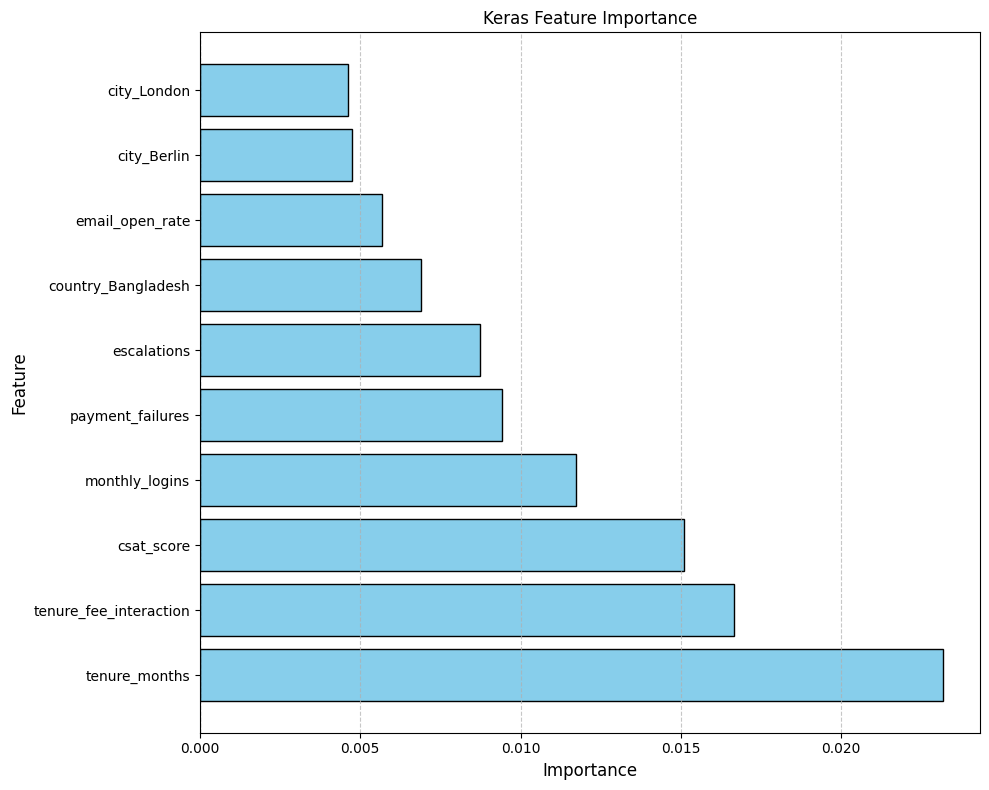

In [ ]:
# Plot the important features and importance_means
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in KE5_feature_importance_df['score']]
plt.barh(KE5_feature_importance_df['feature'], KE5_feature_importance_df['score'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Keras Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Model Summary**     
A dataframe is plotted to summarize the AUC, accuracy, precision, recall, F2 score and profit/loss for the different Random Forest models.     

The ultimate choice of the predictive model would need to consider the actual relative cost of missing a churner (false negatives - predicted not to churn but churned) and false alarms (false positives - predicted to churn but stayed) in order to determine the optimum mix of precision and recall.  

In [ ]:
# Build a comparison dataframe
keras_models_df = pd.DataFrame({
    'Keras': ['Model KE2','Model KE3','Model KE4','Model KE5'],
    'AUC': [auc_KE2, auc_KE3, auc_KE4, auc_KE5],
    'Accuracy': [accuracy_KE2, accuracy_KE3, accuracy_KE4, accuracy_KE5],
    'Precision': [precision_KE2, precision_KE3, precision_KE4, precision_KE5],
    'Recall': [recall_KE2, recall_KE3, recall_KE4, recall_KE5],
    'F2 Score': [F2_score_KE2, F2_score_KE3, F2_score_KE4, F2_score_KE5],
    'Profit/Loss': [Profit_Loss_KE2, Profit_Loss_KE3, Profit_Loss_KE4, Profit_Loss_KE5],
})
keras_models_df

,Keras,AUC,Accuracy,Precision,Recall,F2 Score,Profit/Loss
0,Model KE2,0.754,0.454660,0.137513,0.912752,0.429022,21940
1,Model KE3,0.807,0.581864,0.173638,0.919463,0.494585,30940
2,Model KE4,0.775,0.601385,0.172973,0.859060,0.479042,23900
3,Model KE5,0.820,0.610831,0.186078,0.932886,0.517498,34620


In [ ]:
# Provide an interactive Plotly plot
fig = go.Figure()

#Primary y-axis
metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F2 Score']

for metric in metrics:
  fig.add_trace(
        go.Scatter(
          x=keras_models_df['Keras'],
          y=keras_models_df[metric],
          mode='lines+markers',
          name=metric,
          yaxis='y1'
        )
    )

# Secondary y-axis
fig.add_trace(
        go.Bar(
          x=keras_models_df['Keras'],
          y=keras_models_df['Profit/Loss'],
          name='Profit/Loss',
          yaxis='y2',
          opacity=0.35
        )
)
# Layout
fig.update_layout(
        title='Model Performance and Profit/Loss',
        xaxis=dict(title='Random Forest'),
        yaxis=dict(
            title='Score',
            range=[0, 1]
        ),
        yaxis2=dict(
            title='Profit/Loss ($)',
            overlaying='y',
            side='right'
        ),
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='right',
            x=1
        ),
        template='plotly_white',
        hovermode='x unified'
)
fig.show()

In [ ]:
# Output the best Decision Tree model performance metrics based on profit/loss
keras_metrics_df = keras_models_df.loc[[keras_models_df["Profit/Loss"].idxmax()]]

keras_metrics_df.to_csv("keras_metrics.csv", index=False)

keras_metrics_df.head()

,Keras,AUC,Accuracy,Precision,Recall,F2 Score,Profit/Loss
3,Model KE5,0.82,0.610831,0.186078,0.932886,0.517498,34620


In [ ]:
# Output the first eight (8) features importance
model = keras_metrics_df.iloc[0, 0]

if model == 'Model KE2':
  print(KE2_feature_importance_df.head(8), '\n')
  KE2_feature_importance_df.to_csv("keras_features.csv", index=False)
elif model == 'Model KE3':
  print(KE3_feature_importance_df.head(8), '\n')
  KE3_feature_importance_df.to_csv("keras_features.csv", index=False)
elif model == 'Model KE4':
  print(KE4_feature_importance_df.head(8), '\n')
  KE4_feature_importance_df.to_csv("keras_features.csv", index=False)
else:
  print(KE5_feature_importance_df.head(8), '\n')
  KE5_feature_importance_df.to_csv("keras_features.csv", index=False)

print(f'The best model is {model}.')

                     feature     score
Rank                                  
1              tenure_months  0.023173
2     tenure_fee_interaction  0.016654
3                 csat_score  0.015109
4             monthly_logins  0.011718
5           payment_failures  0.009414
6                escalations  0.008731
7         country_Bangladesh  0.006908
8            email_open_rate  0.005684 

The best model is Model KE5.


**Sample Predictions**

In [ ]:
# Establish best model
model = keras_metrics_df.iloc[0, 0]

if model == 'Model KE2':
  model_opt = grid_result_opt
  best_threshold = threshold_KE2
elif model == 'Model KE3':
  model_opt = grid_search_KE3_opt
  best_threshold = threshold_KE3
elif model == 'Model KE4':
  model_opt = grid_search_KE4_opt
  best_threshold = threshold_KE4
else:
  model_opt = grid_search_KE5_opt
  best_threshold = threshold_KE5

print(f'The best model is {model} and the best threshold is {best_threshold}.')

The best model is Model KE5 and the best threshold is 0.4.


**Sample 1**

In [ ]:
# Obtain a sample from the test data
df_test1 = X_test[264:265]

print(df_test1.head().T, '\n')
print(f'Actual churn is {list(y_test[264:265])[0]}') # verify churn

                                 1862
gender                         Female
age                                62
country                        Canada
city                           Sydney
customer_segment           Individual
tenure_months                      18
signup_channel               Referral
contract_type                 Monthly
monthly_logins                     19
weekly_active_days                  1
avg_session_time            23.353293
features_used                       5
usage_growth_rate               -0.01
last_login_days_ago                 5
monthly_fee                        50
payment_method          Bank Transfer
payment_failures                    2
discount_applied                   No
price_increase_last_3m             No
support_tickets                     2
avg_resolution_time         24.419612
complaint_type                Billing
csat_score                        3.0
escalations                         0
email_open_rate                  0.33
marketing_cl

In [ ]:
# Transfer the data to a dictionary
sample1 = {
    "gender": "Female",
    "age": 62,
    "country": "Canada",
    "city": "Sydney",
    "customer_segment": "Individual",
    "tenure_months": 18,
    "signup_channel": "Referral",
    "contract_type": "Monthly",
    "monthly_logins": 19,
    "weekly_active_days": 1,
    "avg_session_time": 23.353293,
    "features_used": 5,
    "usage_growth_rate": -0.01,
    "last_login_days_ago": 5,
    "monthly_fee": 50,
    "payment_method": "Bank Transfer",
    "payment_failures": 2,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 2,
    "avg_resolution_time": 24.419612,
    "complaint_type": "Billing",
    "csat_score": 3.0,
    "escalations": 0,
    "email_open_rate": 0.33,
    "marketing_click_rate": 0.49,
    "nps_score": -15,
    "survey_response": "Satisfied",
    "referral_count": 1,
    "tenure_fee_interaction": 900
}

In [ ]:
# Calculate churn probability of the sample and provide churn of the sample
probability1 = float(model_opt.predict_proba(pd.DataFrame([sample1]))[0])

if probability1 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability1:.2f}')

The predicted churn is 0 

The predicted churn probability is 0.30


**Sample 2**

In [ ]:
# Obtain a sample from the test data
df_test2 = X_test[399:400]

print(df_test2.head().T, '\n')
print(f'The actual churn is {list(y_test[399:400])[0]}') # verify churn

                             1495
gender                       Male
age                            33
country                     India
city                     New York
customer_segment              SME
tenure_months                  40
signup_channel             Mobile
contract_type           Quarterly
monthly_logins                 10
weekly_active_days              2
avg_session_time        20.705153
features_used                   4
usage_growth_rate           -0.33
last_login_days_ago             0
monthly_fee                    50
payment_method               Card
payment_failures                0
discount_applied               No
price_increase_last_3m         No
support_tickets                 0
avg_resolution_time     31.927794
complaint_type          Technical
csat_score                    3.0
escalations                     0
email_open_rate              0.17
marketing_click_rate         0.15
nps_score                      70
survey_response           Neutral
referral_count

In [ ]:
# Transfer the data to a dictionary
sample2 = {
    "gender": "Male",
    "age": 33,
    "country": "India",
    "city": "New York",
    "customer_segment": "SME",
    "tenure_months": 40,
    "signup_channel": "Mobile",
    "contract_type": "Quarterly",
    "monthly_logins": 10,
    "weekly_active_days": 2,
    "avg_session_time": 20.705153,
    "features_used": 4,
    "usage_growth_rate": -0.33,
    "last_login_days_ago": 0,
    "monthly_fee": 50,
    "payment_method": "Card",
    "payment_failures": 0,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 0,
    "avg_resolution_time": 31.927794,
    "complaint_type": "Technical",
    "csat_score": 3.0,
    "escalations": 0,
    "email_open_rate": 0.17,
    "marketing_click_rate": 0.15,
    "nps_score": 70,
    "survey_response": "Neutral",
    "referral_count": 2,
    "tenure_fee_interaction": 2000
}

In [ ]:
# Calculate churn probability of the sample and provide churn of the sample
probability2 = float(model_opt.predict_proba(pd.DataFrame([sample2]))[0])

if probability2 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability2:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.73


**Sample 3**

In [ ]:
# Obtain a sample from the test data
df_test3 = X_test[999:1000]

print(df_test3.head().T, '\n')
print(f'The actual churn is {list(y_test[999:1000])[0]}') # verify churn

                              5713
gender                      Female
age                             51
country                      India
city                         Dhaka
customer_segment        Individual
tenure_months                   12
signup_channel              Mobile
contract_type            Quarterly
monthly_logins                  12
weekly_active_days               7
avg_session_time         10.737885
features_used                    7
usage_growth_rate            -0.11
last_login_days_ago              4
monthly_fee                     50
payment_method                Card
payment_failures                 0
discount_applied               Yes
price_increase_last_3m          No
support_tickets                  3
avg_resolution_time      23.828534
complaint_type             Billing
csat_score                     4.0
escalations                      0
email_open_rate               0.18
marketing_click_rate          0.48
nps_score                       40
survey_response     

In [ ]:
# Place the sample data in a dictionary
sample3 = {
    "gender": "Female",
    "age": 51,
    "country": "India",
    "city": "Dhaka",
    "customer_segment": "Individual",
    "tenure_months": 12,
    "signup_channel": "Mobile",
    "contract_type": "Quarterly",
    "monthly_logins": 12,
    "weekly_active_days": 7,
    "avg_session_time": 10.737885,
    "features_used": 7,
    "usage_growth_rate": -0.11,
    "last_login_days_ago": 4,
    "monthly_fee": 50,
    "payment_method": "Card",
    "payment_failures": 0,
    "discount_applied": "Yes",
    "price_increase_last_3m": "No",
    "support_tickets": 3,
    "avg_resolution_time": 23.828534,
    "complaint_type": "Billing",
    "csat_score": 4.0,
    "escalations": 0,
    "email_open_rate": 0.18,
    "marketing_click_rate": 0.48,
    "nps_score": 40,
    "survey_response": "Satisfied",
    "referral_count": 2,
    "tenure_fee_interaction": 600
}

In [ ]:
# Calculate churn probability of the sample and provide churn of the sample
probability3 = float(model_opt.predict_proba(pd.DataFrame([sample3]))[0])

if probability3 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability3:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.67


**Sample 4**

In [ ]:
# Obtain another sample from the test data
df_test4 = X_test[125:126]

print(df_test4.head().T, '\n')
print(f'The actual churn is {list(y_test[125:126])[0]}') # verify churn

                                 5786
gender                         Female
age                                51
country                    Bangladesh
city                           London
customer_segment           Individual
tenure_months                      58
signup_channel               Referral
contract_type               Quarterly
monthly_logins                      0
weekly_active_days                  3
avg_session_time            14.899728
features_used                       5
usage_growth_rate                0.11
last_login_days_ago                14
monthly_fee                        20
payment_method          Bank Transfer
payment_failures                    0
discount_applied                   No
price_increase_last_3m             No
support_tickets                     0
avg_resolution_time         13.387985
complaint_type              Technical
csat_score                        4.0
escalations                         0
email_open_rate                  0.22
marketing_cl

In [ ]:
# Place the sample data in a dictionary
sample4 = {
    "gender": "Female",
    "age": 51,
    "country": "Bangladesh",
    "city": "London",
    "customer_segment": "Individual",
    "tenure_months": 58,
    "signup_channel": "Referral",
    "contract_type": "Quarterly",
    "monthly_logins": 0,
    "weekly_active_days": 3,
    "avg_session_time": 14.899728,
    "features_used": 5,
    "usage_growth_rate": 0.11,
    "last_login_days_ago": 14,
    "monthly_fee": 20,
    "payment_method": "Bank Transfer",
    "payment_failures": 0,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 0,
    "avg_resolution_time": 13.387985,
    "complaint_type": "Technical",
    "csat_score": 4.0,
    "escalations": 0,
    "email_open_rate": 0.22,
    "marketing_click_rate": 0.19,
    "nps_score": 50,
    "survey_response": "Satisfied",
    "referral_count": 0,
    "tenure_fee_interaction": 1160
}

In [ ]:
# Calculate churn probability of the sample and provide churn of the sample
probability4 = float(model_opt.predict_proba(pd.DataFrame([sample4]))[0])

if probability4 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability4:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.68


**Sample 5**

In [ ]:
# Obtain another sample from the test data
df_test5 = X_test[1125:1126]

print(df_test5.head().T, '\n')
print(f'The actual churn is {list(y_test[1125:1126])[0]}') # verify churn

                              6970
gender                      Female
age                             38
country                         UK
city                        Sydney
customer_segment        Individual
tenure_months                   14
signup_channel                 Web
contract_type              Monthly
monthly_logins                  10
weekly_active_days               3
avg_session_time         10.354267
features_used                    5
usage_growth_rate            -0.14
last_login_days_ago              3
monthly_fee                     50
payment_method                Card
payment_failures                 1
discount_applied                No
price_increase_last_3m          No
support_tickets                  1
avg_resolution_time       9.362325
complaint_type             Service
csat_score                     3.0
escalations                      0
email_open_rate               0.56
marketing_click_rate          0.49
nps_score                       87
survey_response     

In [ ]:
# Place the sample data in a dictionary
sample5 = {
    "gender": "Female",
    "age": 38,
    "country": "UK",
    "city": "Sydney",
    "customer_segment": "Individual",
    "tenure_months": 14,
    "signup_channel": "Web",
    "contract_type": "Monthly",
    "monthly_logins": 10,
    "weekly_active_days": 3,
    "avg_session_time": 10.354267,
    "features_used": 5,
    "usage_growth_rate": -0.14,
    "last_login_days_ago": 3,
    "monthly_fee": 50,
    "total_revenue": 700,
    "payment_method": "Card",
    "payment_failures": 1,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 1,
    "avg_resolution_time": 9.362325,
    "complaint_type": "Service",
    "csat_score": 3.0,
    "escalations": 0,
    "email_open_rate": 0.56,
    "marketing_click_rate": 0.49,
    "nps_score": 87,
    "survey_response": "Neutral",
    "referral_count": 0,
    "tenure_fee_interaction": 700
}

In [ ]:
# Calculate churn probability of the sample and provide churn of the sample
probability5 = float(model_opt.predict_proba(pd.DataFrame([sample5]))[0])

if probability5 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability5:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.47
